# Reducción de dimensionalidad con UMAP
## Caso Favorita Grocery Sales

**Diplomado Data Engineer — Módulo de Machine Learning**  
**Eduardo Castillo Rodríguez — Máster en Inteligencia Artificial**

En este notebook aplicaremos UMAP sobre la misma matriz de características utilizada en las clases de PCA y t-SNE.


## 1. Instalación de librerías

Instalamos UMAP y Kaleido. Kaleido se utiliza únicamente para exportar los gráficos de Plotly como imágenes PNG.


In [1]:
!pip install -q umap-learn kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 2.2 MB/s eta 0:00:00


## 2. Importación de librerías


In [2]:
import time
import numpy as np
import pandas as pd
import polars as pl
import plotly.express as px
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from umap import UMAP


## 3. Lectura del dataset

El archivo debe estar cargado en la sesión de Google Colab.


In [5]:
df = pl.read_parquet("/content/favorita_weekly.parquet")

## 4. Revisión inicial del dataset


In [6]:
df.head()

fecha_semana,anio,semana,store_nbr,item_nbr,unit_sales,dias_promocion,dias_con_venta
datetime[ns],i16,i8,i16,i32,f32,i8,i8
2012-12-31 00:00:00,2013,1,1,103520,5.0,0,2
2012-12-31 00:00:00,2013,1,1,103665,13.0,0,5
2012-12-31 00:00:00,2013,1,1,105574,26.0,0,5
2012-12-31 00:00:00,2013,1,1,105575,38.0,0,5
2012-12-31 00:00:00,2013,1,1,105577,11.0,0,5


## 5. Dimensiones del dataset


In [7]:
print("Filas:", df.height)
print("Columnas:", df.width)


Filas: 23582329
Columnas: 8


## 6. Tipos de datos


In [8]:
df.schema

Schema([('fecha_semana', Datetime(time_unit='ns', time_zone=None)),
        ('anio', Int16),
        ('semana', Int8),
        ('store_nbr', Int16),
        ('item_nbr', Int32),
        ('unit_sales', Float32),
        ('dias_promocion', Int8),
        ('dias_con_venta', Int8)])

## 7. Valores nulos


In [9]:
df.null_count()

fecha_semana,anio,semana,store_nbr,item_nbr,unit_sales,dias_promocion,dias_con_venta
u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0


## 8. Registros duplicados


In [10]:
duplicados = df.height - df.unique().height
print("Registros duplicados:", duplicados)

Registros duplicados: 0


## 9. Eliminación de duplicados


In [11]:
df = df.unique()
print("Filas después de eliminar duplicados:", df.height)

Filas después de eliminar duplicados: 23582329


## 10. Conversión de la fecha


In [14]:
df = df.with_columns(
    pl.col("fecha_semana").cast(pl.Date)
)

df.head()

fecha_semana,anio,semana,store_nbr,item_nbr,unit_sales,dias_promocion,dias_con_venta
date,i16,i8,i16,i32,f32,i8,i8
2017-01-23,2017,4,13,1345072,17.0,0,5
2016-07-25,2016,30,51,1473414,205.031006,0,7
2013-01-14,2013,3,27,699687,1.852,0,1
2014-01-06,2014,2,7,1693645,50.0,0,7
2015-09-14,2015,38,51,1695887,65.717003,1,6


## 11. Creación de variables temporales

Se construye la semana, el año y el mes de cada transacción.


In [16]:
df = df.with_columns([
    pl.col("fecha_semana").dt.truncate("1w").alias("semana"),
    pl.col("fecha_semana").dt.year().alias("anio"),
    pl.col("fecha_semana").dt.month().alias("mes")
])

df.head()

fecha_semana,anio,semana,store_nbr,item_nbr,unit_sales,dias_promocion,dias_con_venta,mes
date,i32,date,i16,i32,f32,i8,i8,i8
2017-01-23,2017,2017-01-23,13,1345072,17.0,0,5,1
2016-07-25,2016,2016-07-25,51,1473414,205.031006,0,7,7
2013-01-14,2013,2013-01-14,27,699687,1.852,0,1,1
2014-01-06,2014,2014-01-06,7,1693645,50.0,0,7,1
2015-09-14,2015,2015-09-14,51,1695887,65.717003,1,6,9


## 12. Selección de los 5.000 productos con mayor volumen de ventas


In [17]:
top_productos = (
    df.group_by("item_nbr")
      .agg(pl.col("unit_sales").sum().alias("ventas_totales"))
      .sort("ventas_totales", descending=True)
      .head(5000)
)

productos_seleccionados = top_productos["item_nbr"].to_list()

print("Productos seleccionados:", len(productos_seleccionados))

Productos seleccionados: 4036


## 13. Filtrado de productos


In [18]:
df_filtrado = df.filter(
    pl.col("item_nbr").is_in(productos_seleccionados)
)

print("Filas después del filtro:", df_filtrado.height)

Filas después del filtro: 23582329


## 14. Agregación por tienda, semana y producto

Se suman las ventas de cada producto dentro de cada combinación tienda-semana.


In [19]:
ventas_semanales = (
    df_filtrado
    .group_by(["store_nbr", "semana", "anio", "mes", "item_nbr"])
    .agg(
        pl.col("unit_sales").sum().alias("ventas")
    )
)

ventas_semanales.head()

store_nbr,semana,anio,mes,item_nbr,ventas
i16,date,i32,i8,i32,f32
40,2016-09-12,2016,9,1916577,103.0
43,2015-05-25,2015,5,1416362,69.0
15,2014-06-30,2014,6,469643,14.0
23,2015-06-22,2015,6,1463619,5.0
1,2014-10-13,2014,10,640286,1.0


## 15. Construcción de la matriz de características

Cada fila representa una combinación tienda-semana y cada columna representa un producto.


In [20]:
inicio = time.time()

matriz = (
    ventas_semanales
    .pivot(
        index=["store_nbr", "semana", "anio", "mes"],
        on="item_nbr",
        values="ventas",
        aggregate_function="sum"
    )
    .fill_null(0)
    .sort(["store_nbr", "semana"])
)

print("Tiempo del pivot:", round(time.time() - inicio, 2), "segundos")
print("Dimensiones:", matriz.shape)

Tiempo del pivot: 7.86 segundos
Dimensiones: (12060, 4040)


## 16. Separación de metadatos y variables


In [21]:
columnas_meta = ["store_nbr", "semana", "anio", "mes"]
columnas_productos = [
    columna for columna in matriz.columns
    if columna not in columnas_meta
]

metadata = matriz.select(columnas_meta).to_pandas()
X = matriz.select(columnas_productos).to_numpy()

print("Matriz de variables:", X.shape)
print("Metadatos:", metadata.shape)

Matriz de variables: (12060, 4036)
Metadatos: (12060, 4)


## 17. Dispersión de la matriz

Se calcula el porcentaje de valores iguales a cero.


In [22]:
porcentaje_ceros = np.mean(X == 0) * 100
print(f"Porcentaje de valores en cero: {porcentaje_ceros:.2f}%")

Porcentaje de valores en cero: 51.55%


## 18. Estandarización de las variables

UMAP utiliza distancias entre observaciones. Por esta razón, las variables deben estar en una escala comparable.


In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Matriz estandarizada:", X_scaled.shape)

Matriz estandarizada: (12060, 4036)


## 19. Reducción previa con PCA

Antes de aplicar UMAP, reducimos la matriz a 50 componentes principales. Esto disminuye el tiempo de procesamiento y elimina parte del ruido.


In [24]:
pca = PCA(
    n_components=50,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)

print("Matriz original:", X_scaled.shape)
print("Matriz después de PCA:", X_pca.shape)
print(
    "Varianza acumulada:",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

Matriz original: (12060, 4036)
Matriz después de PCA: (12060, 50)
Varianza acumulada: 63.13 %


## 20. Aplicación de UMAP

Parámetros utilizados:

- `n_neighbors=30`: considera aproximadamente 30 observaciones cercanas.
- `min_dist=0.1`: permite formar agrupaciones relativamente compactas.
- `n_components=2`: genera una representación bidimensional.
- `random_state=42`: permite reproducir el resultado.


In [25]:
inicio = time.time()

modelo_umap = UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    metric="euclidean",
    random_state=42
)

X_umap = modelo_umap.fit_transform(X_pca)

print("Tiempo UMAP:", round(time.time() - inicio, 2), "segundos")
print("Dimensiones del resultado:", X_umap.shape)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Tiempo UMAP: 34.21 segundos
Dimensiones del resultado: (12060, 2)


## 21. DataFrame con las coordenadas UMAP


In [26]:
resultado_umap = metadata.copy()

resultado_umap["UMAP 1"] = X_umap[:, 0]
resultado_umap["UMAP 2"] = X_umap[:, 1]

resultado_umap["store_nbr"] = resultado_umap["store_nbr"].astype(str)
resultado_umap["anio"] = resultado_umap["anio"].astype(str)
resultado_umap["mes"] = resultado_umap["mes"].astype(str)

resultado_umap.head()

,store_nbr,semana,anio,mes,UMAP 1,UMAP 2
0,1,2012-12-31,2012,12,-2.215940,-3.861320
1,1,2013-01-07,2013,1,-2.164044,-3.813929
2,1,2013-01-14,2013,1,-2.166075,-3.815564
3,1,2013-01-21,2013,1,-2.171810,-3.821369
4,1,2013-01-28,2013,1,-2.146933,-3.796133


## 22. Visualización general de UMAP

Cada punto representa una observación tienda-semana.


In [29]:
fig = px.scatter(
    resultado_umap,
    x="UMAP 1",
    y="UMAP 2",
    hover_data=["store_nbr", "semana", "anio", "mes"],
    title="Mapa UMAP de las observaciones tienda-semana",
    opacity=0.7
)

modelo = UMAP(
    n_neighbors=20,
    min_dist=0.05,
    random_state=42
)

fig.update_traces(marker=dict(size=5))
fig.show()

Cada punto representa una observación (tienda–semana). UMAP proyecta datos de alta dimensionalidad en dos dimensiones, permitiendo identificar visualmente agrupaciones, patrones y posibles anomalías.

## 23. Visualización coloreada por tienda


In [30]:
fig_tienda = px.scatter(
    resultado_umap,
    x="UMAP 1",
    y="UMAP 2",
    color="store_nbr",
    hover_data=["semana", "anio", "mes"],
    title="Mapa UMAP coloreado por tienda",
    opacity=0.7
)

fig_tienda.update_traces(marker=dict(size=5))
fig_tienda.show()

Al colorear las observaciones según la tienda, se aprecia que cada una ocupa distintas regiones del espacio UMAP. Esto indica que el algoritmo captura patrones característicos de comportamiento, aunque algunas zonas son compartidas por varias tiendas debido a similitudes en sus perfiles de venta.

## 24. Visualización coloreada por año


In [31]:
fig_anio = px.scatter(
    resultado_umap,
    x="UMAP 1",
    y="UMAP 2",
    color="anio",
    hover_data=["store_nbr", "semana", "mes"],
    title="Mapa UMAP coloreado por año",
    opacity=0.7
)

fig_anio.update_traces(marker=dict(size=5))
fig_anio.show()

El coloreado por año muestra que las observaciones de distintos períodos se distribuyen a lo largo del mapa UMAP. Esto indica que el comportamiento de las ventas presenta continuidad en el tiempo y que los patrones identificados no dependen exclusivamente del año de observación.

## 25. Visualización coloreada por mes


In [32]:
fig_mes = px.scatter(
    resultado_umap,
    x="UMAP 1",
    y="UMAP 2",
    color="mes",
    hover_data=["store_nbr", "semana", "anio"],
    title="Mapa UMAP coloreado por mes",
    opacity=0.7
)

fig_mes.update_traces(marker=dict(size=5))
fig_mes.show()

El coloreado por mes muestra una alta mezcla entre las observaciones de todos los meses. Esto sugiere que la estacionalidad mensual, por sí sola, no explica los patrones identificados por UMAP.

## 26. Gráfico limpio para la presentación


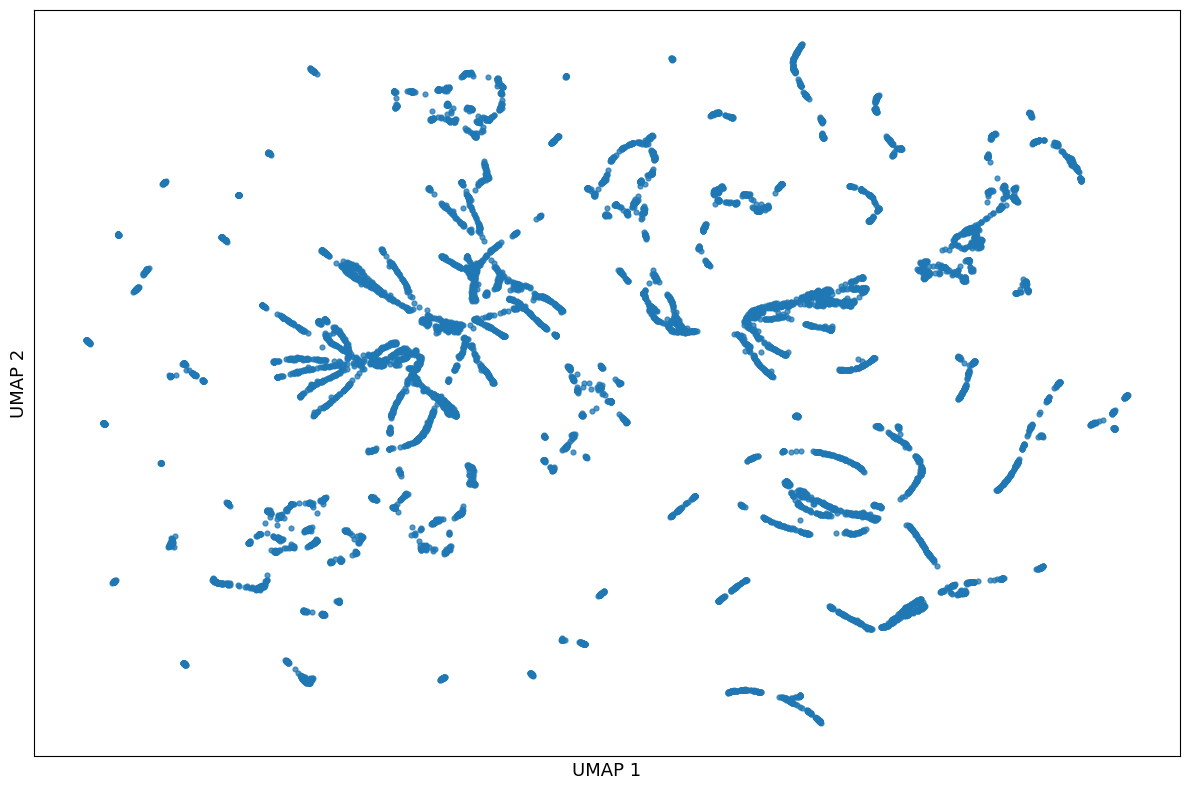

In [34]:
plt.figure(figsize=(12,8))

plt.scatter(
    resultado_umap["UMAP 1"],
    resultado_umap["UMAP 2"],
    s=12,              # puntos un poco más grandes
    alpha=0.75
)

# Sin título (la diapositiva ya tiene uno)
plt.xlabel("UMAP 1", fontsize=13)
plt.ylabel("UMAP 2", fontsize=13)

# Quitar numeración de los ejes
plt.xticks([])
plt.yticks([])

# Mantener un borde limpio
plt.grid(False)

plt.tight_layout()

plt.savefig(
    "umap_presentacion.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True      # fondo transparente para Gamma
)

plt.show()

Cada punto representa una observación correspondiente a una combinación tienda–semana. UMAP proyecta datos de alta dimensionalidad en dos dimensiones, preservando las relaciones de similitud entre las observaciones y facilitando la identificación de agrupaciones, patrones y posibles anomalías.

## 27. Exportación de las coordenadas UMAP


In [37]:
resultado_umap.to_csv(
    "coordenadas_umap_favorita.csv",
    index=False
)

print("Archivo exportado correctamente.")

Archivo exportado correctamente.


# Interpretación

- Los puntos cercanos representan observaciones con comportamientos similares.
- Las agrupaciones permiten reconocer patrones en los datos.
- Las regiones separadas representan perfiles diferentes.
- Los puntos aislados pueden corresponder a observaciones atípicas.
- Los ejes UMAP 1 y UMAP 2 no tienen significado físico directo.
- Las distancias globales no deben interpretarse como medidas exactas.
